# Checking duL between Profiler and QG calculation

In [1]:
# imports
import os

import xarray
import pandas

import numpy as np
# import fsspec
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from profiler.gliderdata import SprayData
from profiler.profilerpairs import ProfilerPairs
from profiler import io as p_io

# Load up

In [2]:
# Generated by writing the intermediate output from qg_100km.py 
SFtest =  xarray.open_dataset('SFtest.nc')

In [3]:
SFtest

<xarray.Dataset> Size: 3GB
Dimensions:  (dcorr: 1740, x: 26, y: 26, time: 100)
Coordinates:
  * x        (x) float64 208B 4.512e+05 4.551e+05 ... 5.449e+05 5.488e+05
  * y        (y) float64 208B 4.512e+05 4.551e+05 ... 5.449e+05 5.488e+05
  * time     (time) float64 800B 4.321e+08 4.322e+08 ... 4.406e+08 4.406e+08
    lev      int64 8B ...
Dimensions without coordinates: dcorr
Data variables:
    dr       (dcorr, x, y, time) float64 941MB ...
    ulls     (dcorr, x, y, time) float64 941MB ...
    utts     (dcorr, x, y, time) float64 941MB ...

In [4]:
SFtest.x.values[0]

np.float64(451171.875)

In [5]:
SFtest = SFtest.isel(time=0)

In [6]:
np.sum(np.isfinite(SFtest.dr))

<xarray.DataArray 'dr' ()> Size: 8B
array(228150)
Coordinates:
    lev      int64 8B ...
    time     float64 8B 4.321e+08

## Gliders

In [7]:
# Gliders
gliders_df = pandas.read_csv('QG/data/stationary_gliders_ts5001_nd100_df.csv')
gliders_df.head()

,x,y,time,missid,x_m,y_m,u_qg,v_qg
0,115.0,115.0,432086400.0,0,451171.875,451171.875,-0.031685,0.020684
1,116.0,115.0,432086400.0,1,455078.125,451171.875,-0.032276,0.050447
2,117.0,115.0,432086400.0,2,458984.375,451171.875,-0.033166,0.070154
3,118.0,115.0,432086400.0,3,462890.625,451171.875,-0.035052,0.057872
4,119.0,115.0,432086400.0,4,466796.875,451171.875,-0.036180,0.032670


## Cut down to the first time stamp

In [8]:
gliders_df = gliders_df[gliders_df.time == 432086400.0]
len(gliders_df)

676

# Profiler

In [9]:
gliders_df

,x,y,time,missid,x_m,y_m,u_qg,v_qg
0,115.0,115.0,432086400.0,0,451171.875,451171.875,-0.031685,0.020684
1,116.0,115.0,432086400.0,1,455078.125,451171.875,-0.032276,0.050447
2,117.0,115.0,432086400.0,2,458984.375,451171.875,-0.033166,0.070154
3,118.0,115.0,432086400.0,3,462890.625,451171.875,-0.035052,0.057872
4,119.0,115.0,432086400.0,4,466796.875,451171.875,-0.036180,0.032670
...,...,...,...,...,...,...,...,...
671,136.0,140.0,432086400.0,671,533203.125,548828.125,0.042372,-0.008069
672,137.0,140.0,432086400.0,672,537109.375,548828.125,0.033438,-0.024818
673,138.0,140.0,432086400.0,673,541015.625,548828.125,0.026552,-0.038659
674,139.0,140.0,432086400.0,674,544921.875,548828.125,0.020740,-0.051160


In [11]:
meta = {}
# Build SprayData objects — one per glider
gliders = SprayData.all_from_QG_glider(gliders_df, meta)

# Set x,y distance
for ss, glider in enumerate(gliders):
    idf = gliders_df.iloc[ss]
    glider.distE = np.array([idf.x_m/1e3])
    glider.distN = np.array([idf.y_m/1e3])

# Construct ProfilerPairs
pairs = ProfilerPairs(
    gliders,
    max_time=1.,
    avoid_same_glider=True,
    skip_dist=True,
    randomize=False,
)
pairs.calc_delta(iz=0, variables='duLduLduL')

In [12]:
gliders[0].distE

array([451.171875])

In [13]:
pairs.r.min()

np.float64(3.90625)

# dr histograms

In [14]:
pairs.r.max()

np.float64(138.10679320049758)

In [15]:
imax = np.argmax(pairs.r)
imax

np.int64(674)

In [16]:
pairs.duL[imax]

np.float64(-0.027066669814136635)

In [17]:
pairs.data('distN',0)[imax], pairs.data('distE',0)[imax]

(np.float64(451.171875), np.float64(451.171875))

In [18]:
pairs.data('distN',1)[imax], pairs.data('distE',1)[imax]

(np.float64(548.828125), np.float64(548.828125))

In [19]:
pairs.data('missida',0)[imax], pairs.data('missida',1)[imax]

(np.int64(0), np.int64(675))

In [20]:
good_dr = np.isfinite(SFtest.dr.values)
SFtest.dr.values[good_dr].flatten().min()/1e3, SFtest.dr.values[good_dr].flatten().max()/1e3

(np.float64(3.90625), np.float64(138.10679320049758))

In [21]:
25*np.sqrt(2)*3.90625

np.float64(138.10679320049758)

In [22]:
rsrt = np.argsort(SFtest.dr.values[good_dr].flatten())

In [23]:
SFtest.dr.values[good_dr].flatten()[rsrt[-3:]]

array([135372.83946221, 138106.7932005 , 138106.7932005 ])

In [24]:
SFtest.ulls.values[good_dr][rsrt[-2:]]

array([ 0.08054031, -0.02706667])

In [25]:
iSFmax = np.argmax(SFtest.dr.values[good_dr].flatten())
iSFmax

np.int64(227474)

In [26]:
SFtest.ulls.values[good_dr][iSFmax]

np.float64(0.08054030501500417)

In [27]:
SFtest.dr.values[good_dr][iSFmax]

np.float64(138106.79320049757)

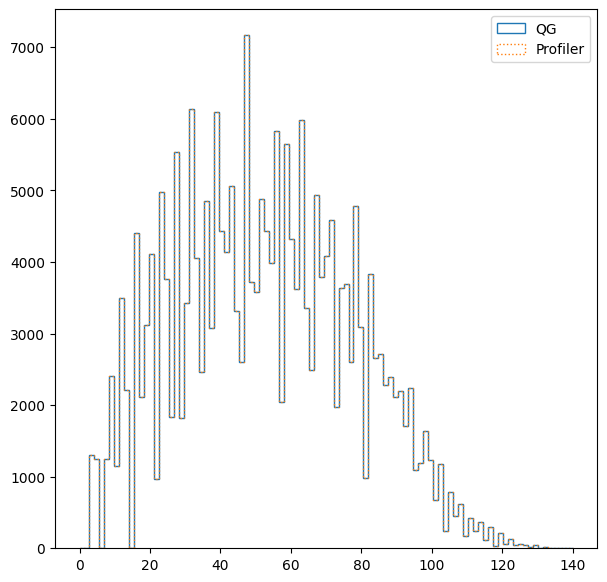

In [28]:
rbins = np.linspace(0., 140., 100)

fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.hist(SFtest.dr.values.flatten()/1e3, bins=rbins, label='QG', histtype='step')
ax.hist(pairs.r, bins=rbins, label='Profiler', histtype='step', linestyle='dotted')

ax.legend()
plt.show()

# Hopefully good enough..

----

# Velocities

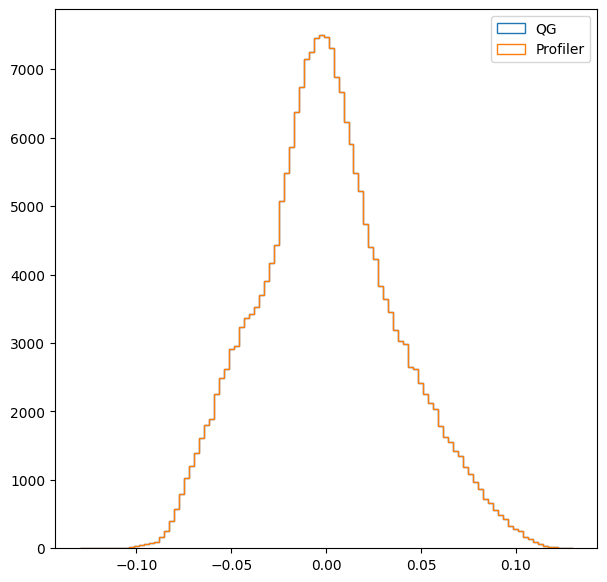

In [29]:
ubins = np.linspace(-0.13, 0.13, 100)
#ubins = None

fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.hist(SFtest.ulls.values.flatten(), bins=ubins, label='QG', histtype='step')
ax.hist(pairs.duL, bins=ubins, label='Profiler', histtype='step')#, linestyle='dotted')

ax.legend()
plt.show()

# Average around dr = 70km

In [30]:
dr = 5.
rbins = np.arange(0, 1.3e2, dr) # 130 km
rbins

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125.])

## QG

In [31]:
in_bin_qg = np.abs(SFtest.dr.values.flatten()/1e3 - 72.5) < 2.5 
avg_ul_qg = np.mean(SFtest.ulls.values.flatten()[in_bin_qg])
np.sum(in_bin_qg), avg_ul_qg

(np.int64(12842), np.float64(0.0007393407483181353))

## Gliders

In [32]:
in_bin_g = np.abs(pairs.r - 72.5) < 2.5 
avg_ul_g = np.mean(pairs.duL[in_bin_g])
np.sum(in_bin_g), avg_ul_g

(np.int64(12842), np.float64(0.000739340748318132))